### Spatial view and frequency view
The three code vells below produce two images one, frequency view and the other a sptial view of an image from the dataset

In [90]:
'''
Imports and loading dataset.
'''

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy.ndimage import sobel

ROOT = Path("Bird Speciees Dataset")  
IMAGE_SIZE = (224,224)

paths = sorted(
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

if not paths:
    raise FileNotFoundError(f"No images found in {ROOT.resolve()}")

print(f"{len(paths)} images")

811 images


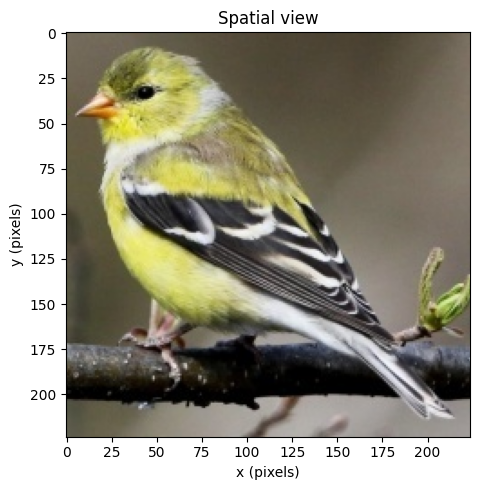

In [91]:
used_image = paths[0]  # Change this index to use a different image
arr = np.asarray(Image.open(used_image).convert("RGB"))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(arr)
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title("Spatial view")
plt.tight_layout()
plt.show()

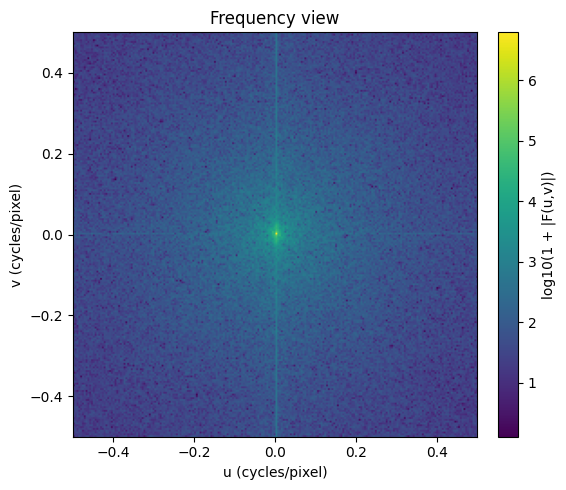

In [92]:
# Mean image across the dataset
mean_img = np.zeros((*IMAGE_SIZE, 3), dtype=np.float64)
for p in paths:
    mean_img += np.asarray(Image.open(p).convert("RGB"), dtype=np.float64)
mean_img /= len(paths)
gray = mean_img.mean(axis=2)

# 2-D FFT
F = np.fft.fftshift(np.fft.fft2(gray))
mag = np.log10(1 + np.abs(F))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    mag,
    extent=[-0.5, 0.5, -0.5, 0.5],
    origin="lower",
    cmap="viridis",
)
ax.set_xlabel("u (cycles/pixel)")
ax.set_ylabel("v (cycles/pixel)")
ax.set_title("Frequency view")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("log10(1 + |F(u,v)|)")
plt.tight_layout()
plt.show()

Copied from p1.md 
### Transformation experiment
For the experiment the transformation that will be used is sobel edge detection. 

**Prediction:** The Sobel edge detection will produce stronger and more
accurate responses at high-contrast features such as the birds beak and eye,
and weaker responses across the body where brightness changes are more
gradual. The strength of the birds outline will also depend on the
contrast between the bird and its background. For example, a penguins
white stomach will produce a weaker outline against a snowy background.

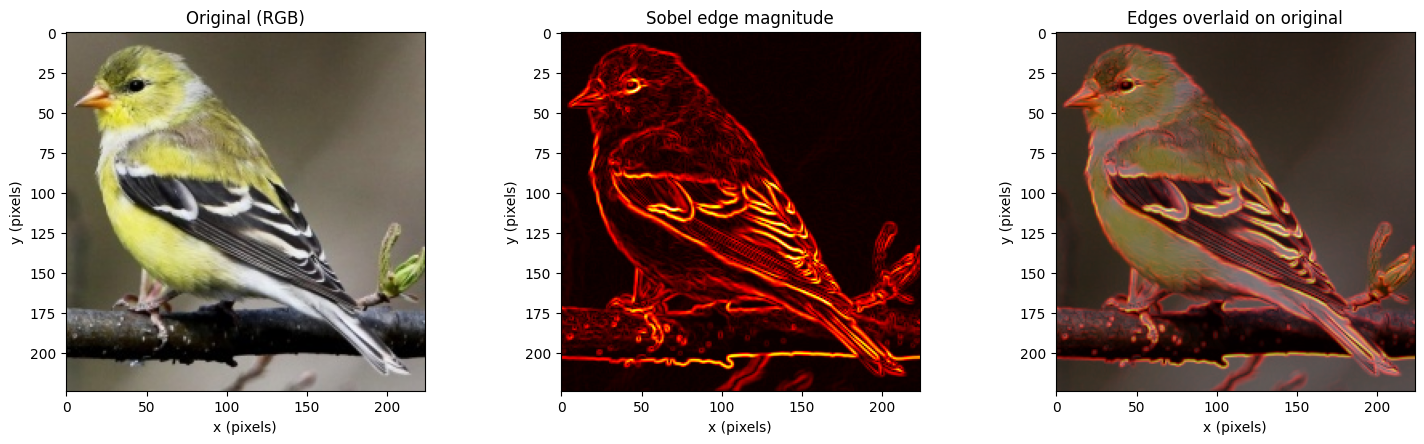

In [93]:


paths = [p for p in ROOT.rglob("*")
         if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]

# One image — load RGB and grayscale

rgb  = np.asarray(Image.open(used_image).convert("RGB"))
gray = np.asarray(Image.open(used_image).convert("L"), dtype=np.float64)

# Sobel edges
gx = sobel(gray, axis=1)
gy = sobel(gray, axis=0)
mag = np.hypot(gx, gy)

# Show original, edges, and overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(rgb)
axes[0].set_title("Original (RGB)")
axes[0].set_xlabel("x (pixels)"); axes[0].set_ylabel("y (pixels)")

axes[1].imshow(mag, cmap="hot")
axes[1].set_title("Sobel edge magnitude")
axes[1].set_xlabel("x (pixels)"); axes[1].set_ylabel("y (pixels)")

axes[2].imshow(rgb)
axes[2].imshow(mag, cmap="hot", alpha=0.5)
axes[2].set_title("Edges overlaid on original")
axes[2].set_xlabel("x (pixels)"); axes[2].set_ylabel("y (pixels)")

plt.tight_layout()
plt.show()

### How much signal can be removed before one cannot identify the bird?

To determine this, first the signal of an average of all images of each bird will be calculated. 

In [94]:

# All images shall be grayscale, then create the per-bird average images.



###  Resampling/quantisation experiment that finds artefacts/limitations
For this task we went with doing quantisation to see the effect upon the image by gradually reducing the allowed intensity values in the images. 
***Prediction:*** Because the birds themselves contain few colours, with sudden transitions rather than gradual ones in their features, we predict the birds will not be strongly affected by quantisation until lower bit levels. Meanwhile, the background in many images contains very gradual colour changes and will therefore be heavily affected by artefacts, or even destroyed, by quantisation



 bits  levels  unique vals   mean error
    8     256          256         0.00
    6      64           64         1.00
    4      16           16         4.16
    3       8            8         8.95
    2       4            4        19.71
    1       2            2        78.10


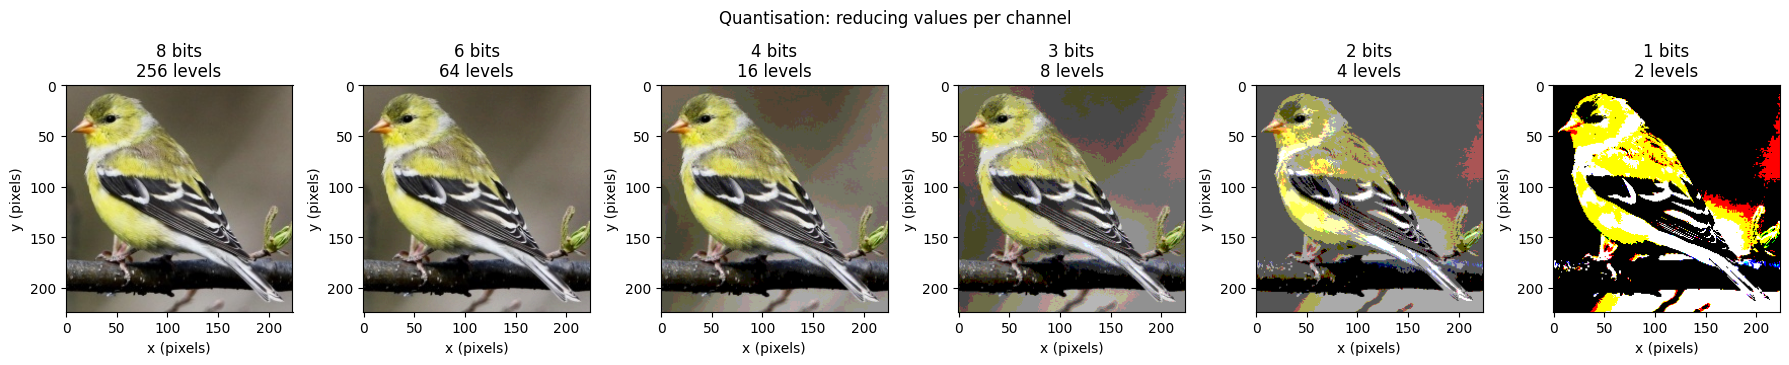

In [95]:
img = np.asarray(Image.open(used_image).convert("RGB"), dtype=np.uint8)

def quantise(arr, bits):
    levels = 2**bits
    step = 255 / (levels - 1)
    q = np.round(arr / step) * step
    return np.clip(q, 0, 255).astype(np.uint8)

bit_levels = [8, 6, 4, 3, 2, 1]

# Numeric summary
print(f"{'bits':>5s} {'levels':>7s} {'unique vals':>12s} {'mean error':>12s}")
for b in bit_levels:
    q = quantise(img, b)
    unique = len(np.unique(q))
    err = np.abs(img.astype(int) - q.astype(int)).mean()
    print(f"{b:>5d} {2**b:>7d} {unique:>12d} {err:>12.2f}")

# Visual grid
fig, axes = plt.subplots(1, len(bit_levels), figsize=(3*len(bit_levels), 3.6))
for ax, b in zip(axes, bit_levels):
    ax.imshow(quantise(img, b))
    ax.set_title(f"{b} bits\n{2**b} levels")
    ax.set_xlabel("x (pixels)"); ax.set_ylabel("y (pixels)")
plt.suptitle("Quantisation: reducing values per channel")
plt.tight_layout()
plt.show()

### Quantisation findings
